# DPRL - Assignment 3 Implementation, group 14

**Disclaimer:**
    All of our code is the result of a collaboration between us and ChatGPT in an iterative manner. Although all of the decision making should be attributed to us (it is an LLM after all, sometimes we ended up just coding parts by ourselves), it proved to be a valuable tool in speeding up the documentation, styling and creative process, helping to push the overall quality of our final notebook upon request.

In [3]:
import math
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

### Encoding of the initial board
- Manually encoded initial board state based on the provided image
- We use 1 for our (MCTS) pieces, 2 for the opponent's, 0 otherwise (empty)
- The board is encoded from left to right and from bottom to top

In [4]:
initial_state = [
    [2, 1, 1, 1, 2, 2, 1],  # Bottom row (Row 1)
    [0, 1, 2, 2, 1, 2, 0],  # Row 2
    [0, 1, 1, 1, 2, 1, 0],  # Row 3
    [0, 2, 2, 2, 1, 2, 0],  # Row 4
    [0, 1, 1, 2, 2, 1, 0],  # Row 5
    [0, 1, 2, 2, 1, 2, 0],  # Top row (Row 6)
] #  1  2  3  4  5  6  7  <- Columns

### Connect4 implementation
- The *__init__* method initializes the game with a given state and sets the MCTS agent to play first.
- The *__str__* method returns a string representation of the game board. Included for ease of debugging and fast visualization purposes while working on the MCTS.
- The *get_possible_actions* method computes the list of columns where a new piece can be legally placed (i.e., not full).
- The *is_terminal* method checks if the game has reached an end state, identifying wins for either player or a draw.
- The *check_winner* method inspects the board for a four-in-a-row condition horizontally, vertically, or diagonally for either player (used by *is_terminal*.
- The *play* method executes a move by placing a piece in the chosen column (only if it's a legal move!) and toggles the player turn, also checking for terminal state after the move.

In [5]:
class Connect4:
    def __init__(self, state):
        self.rows = 6
        self.columns = 7
        self.state = np.array(state)
        self.player_turn = 1  # Set the MCTS as the first player
        
    def __str__(self):
        board_str = ""
        for row in reversed(self.state):  # Reverse the board to start from the top for printing
            board_str += ' '.join(str(cell) for cell in row) + "\n"
        return board_str
    
    def get_possible_actions(self):
        # Actions are possible in columns that are not full (top cell is empty)
        return [c for c in range(self.columns) if self.state[5][c] == 0]

    def is_terminal(self):
        # Check for win in rows, columns, and diagonals for both players
        for player in [1, 2]:
            if self.check_winner(player):
                return True, 1 if player == 1 else -1
        
        # Check for draw (if no empty cells left)
        if not np.any(self.state == 0):
            return True, 0  # Draw
        
        return False, None  # Not a terminal state

    def check_winner(self, player):
        # Check horizontal, vertical, and diagonal (\ and /) for a win
        for row in range(self.rows):
            for col in range(self.columns - 3):
                if all(self.state[row, col:col + 4] == player):
                    return True  # Horizontal win
        for col in range(self.columns):
            for row in range(self.rows - 3):
                if all(self.state[row:row + 4, col] == player):
                    return True  # Vertical win
        for col in range(self.columns - 3):
            for row in range(self.rows - 3):
                if all(self.state[row + i][col + i] == player for i in range(4)):
                    return True  # Diagonal (\) win
                if all(self.state[row + 3 - i][col + i] == player for i in range(4)):
                    return True  # Diagonal (/) win
        return False

    def play(self, action):
        # Check if the column is full
        if self.state[5][action] != 0:
            raise ValueError(f"Column {action + 1} is full. Please choose another column.")

        # Play a piece in the chosen column
        for row in range(self.rows):
            if self.state[row][action] == 0:
                self.state[row][action] = self.player_turn
                break
        
        # Check if this move ends the game
        terminal, reward = self.is_terminal()
        
        # Switch player
        self.player_turn = 3 - self.player_turn
        return terminal, reward

    def get_next_state(self, action):
        # Make sure this method creates a deep copy of the game,
        # plays the move, and returns the new game state
        new_game = copy.deepcopy(self)
        terminal, _ = new_game.play(action)
        return new_game

### Visualizer for the games
 - The *render* method visualizes the game board using matplotlib, indicating the current player or the winner.
- It includes a *find_winning_tiles* method that identifies the four connecting tiles that led to a win, highlighting them in yellow.
- The colors are chosen to be dark blue for the MCTS agent, light blue for the Random agent, with a clear distinction for winning sequences.
- The title dynamically updates to reflect the current state of the game or the outcome if the game has ended.
- A legend is included to identify the MCTS agent and the Random agent with their respective colors.
- Only left undone the handling when the game ends in a draw.

In [97]:
class Connect4Visualizer(Connect4):
    def __init__(self, state, player_turn=1):
        super().__init__(state)
        self.player_turn = player_turn
        
    def find_winning_tiles(self):
        # Check for four consecutive tiles horizontally, vertically, and diagonally
        for player in [1, 2]:
            for row in range(self.rows):
                for col in range(self.columns - 3):
                    if all(self.state[row, col:col + 4] == player):
                        return [(row, col + i) for i in range(4)]
            for col in range(self.columns):
                for row in range(self.rows - 3):
                    if all(self.state[row:row + 4, col] == player):
                        return [(row + i, col) for i in range(4)]
            for col in range(self.columns - 3):
                for row in range(self.rows - 3):
                    if all(self.state[row + i][col + i] == player for i in range(4)):
                        return [(row + i, col + i) for i in range(4)]
                    if all(self.state[row + 3 - i][col + i] == player for i in range(4)):
                        return [(row + 3 - i, col + i) for i in range(4)]
        return []

    def render(self):
        terminal, reward = self.is_terminal()
        winning_tiles = self.find_winning_tiles() if terminal and reward != 0 else []

        # Define colors: white for empty, dark blue for MCTS agent's pieces, light blue for Random agent's pieces
        cmap = ListedColormap(['white', 'darkblue', 'lightblue'])
        fig, ax = plt.subplots()

        # Create a copy of the state to modify for display
        display_state = np.copy(self.state)

        # If we have winning tiles, change their value to a number that's not 1 or 2 to not confuse with player colors
        if winning_tiles:
            for row, col in winning_tiles:
                display_state[row, col] = 3  # Temporary value for winning tiles

        # We flip the y-axis to have the [0][0] at the bottom left corner
        ax.matshow(np.flipud(display_state), cmap=cmap)

        # Highlight winning tiles by changing the color to yellow
        if winning_tiles:
            for row, col in winning_tiles:
                # Flip the row index for display because we've flipped the display array
                ax.add_patch(plt.Rectangle((col - 0.5, 4.5 - row), 1, 1, color='yellow'))

        # Draw gridlines
        for (i, j), val in np.ndenumerate(np.flipud(display_state)):
            ax.text(j, i, '', ha='center', va='center')

        # Set ticks and labels with 1-based numbering
        ax.set_xticks(np.arange(-0.5, 7, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 6, 1), minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
        plt.xticks(range(7), [str(i+1) for i in range(7)])
        plt.yticks(range(6), [str(6-i) for i in range(6)])

        # Hide major tick labels
        ax.tick_params(which='major', top=False, bottom=False, left=False, right=False, labelbottom=True)

        # Set axis labels
        plt.xlabel('Columns')
        plt.ylabel('Rows')

        # Modify title to show the winning agent, current player, or a draw
        if terminal:
            if reward == 0:
                plt.title(f"Game ends in a draw", fontsize=16)
            else:
                winner = "MCTS agent" if reward == 1 else "Random agent"
                plt.title(f"{winner} won!", fontsize=16)
        else:
            player = "MCTS agent" if self.player_turn == 1 else "Random agent"
            plt.title(f"Current state of the game. {player} to play", fontsize=16)

        # Create a legend for the colors without white and yellow
        colors = [plt.plot([],[], color=cmap.colors[i], ls="", marker="s", markersize=np.sqrt(100))[0] for i in [1, 2]]
        labels = ['MCTS agent', 'Random agent']
        plt.legend(colors, labels, numpoints=1, markerscale=1, loc='upper right', bbox_to_anchor=(1.15, 1))

        # Display the game state
        plt.show()

#### First visualization

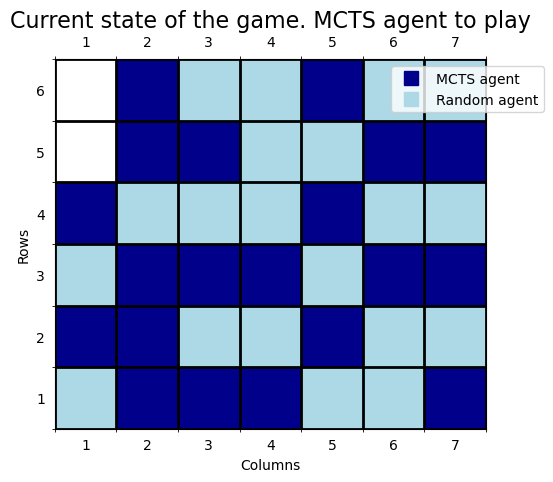

In [102]:
# Initial state visualization
visual_game = Connect4Visualizer(initial_state)
visual_game.render()

#### Some additional testing (the next 4 cells can be ignored)

Possible actions (columns where a piece can be played): [0, 6]

Remember that 1 is MCTS agent, 2 random, 0 empty
Piece in (row,col) = (4,5): 1
Piece in (row,col) = (5,5): 2
Piece in (row,col) = (5,6): 1
Piece in (row,col) = (5,7): 0

Playing in column 1


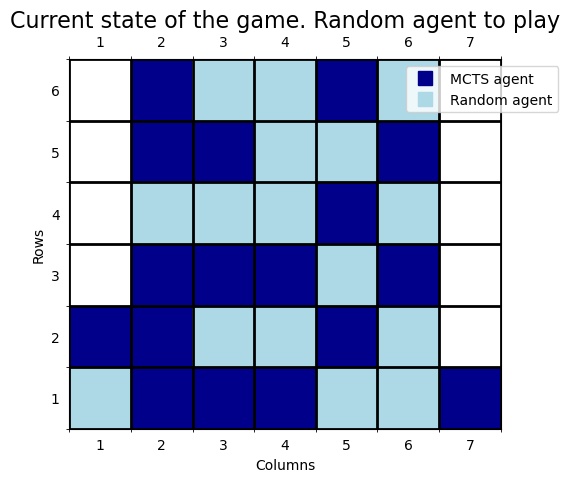

Terminal state reached: False
Reward: None


In [8]:
game = Connect4(initial_state)
possible_actions = game.get_possible_actions()
print("Possible actions (columns where a piece can be played):", possible_actions)


# Checking that the coordinates work as intended
print("\nRemember that 1 is MCTS agent, 2 random, 0 empty\nPiece in (row,col) = (4,5):",game.state[3,4])
print("Piece in (row,col) = (5,5):",game.state[4,4])
print("Piece in (row,col) = (5,6):",game.state[4,5])
print("Piece in (row,col) = (5,7):",game.state[5,6])
print("")

# Now, let's play a piece in one of the possible actions
# For this example, we'll just take the first possible action
action_to_play = possible_actions[0]
print(f"Playing in column {action_to_play + 1}")  # Adding 1 for 1-based indexing

# Play the action and check if the game reaches a terminal state and the reward
terminal, reward = game.play(action_to_play)

# Render the new state of the game
visual_game_after_play = Connect4Visualizer(game.state,game.player_turn)
visual_game_after_play.render()

# Print the result of the play
print("Terminal state reached:", terminal)
print("Reward:", reward)

#### Preventing illegal moves from happening (testing 2/4)

In [9]:
# Illegal move check
game.play(1)

# Render the new state of the game
visual_game_after_play = Connect4Visualizer(game.state,game.player_turn)
visual_game_after_play.render()

ValueError: Column 2 is full. Please choose another column.

#### Checking the visualization updates as expected (testing 3/4)

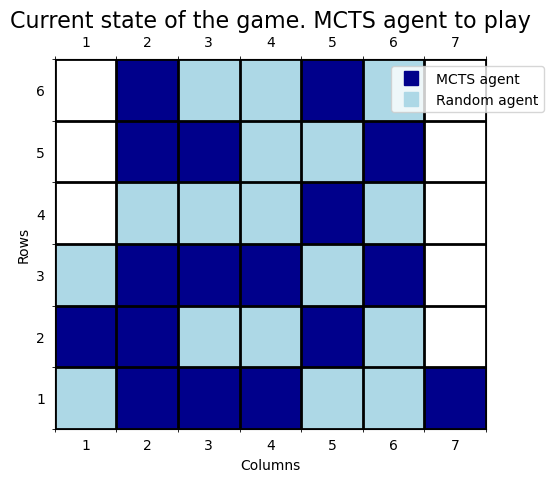

In [10]:
# Light player plays 1st column
game.play(0)

# Render the new state of the game
visual_game_after_play = Connect4Visualizer(game.state,game.player_turn)
visual_game_after_play.render()

#### Reaching terminal state (testing 4/4)

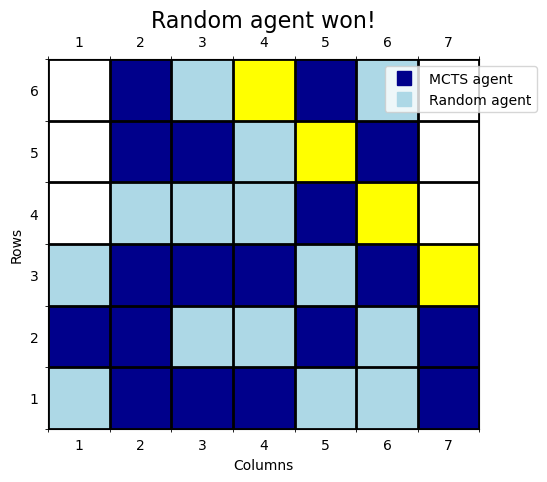

In [11]:
# Dark player plays last column and then light players wins by either playing first or last column
game.play(6)
game.play(6)

# Render the new state of the game
visual_game_after_play = Connect4Visualizer(game.state,game.player_turn)
visual_game_after_play.render()

# MCTS implementation
Main task of the assignment. The implementation is performed by 2 main classes:

## Node Class

The `Node` class represents a single state in the MCTS tree. Each instance of this class corresponds to a possible game state, with connections to parent and child states.

### Initialization Parameters:

- `game`: An instance of the Connect 4 game state.
- `parent` (optional): The parent `Node` object. Default is `None`, used for the root node.
- `move` (optional): The move that led to this game state from the parent node. Default is `None`.

### Methods:

- `uct_select_child()`: Selects the child node with the highest UCT value to navigate the tree during the selection phase of MCTS.
  
- `expand()`: Expands the current node by creating new child nodes for each untried move available in the game state.

- `simulate()`: Performs a random rollout (simulation) from the current node until the game reaches a terminal state.

- `backpropagate(result)`: Propagates the result of a simulation back up the tree, updating the total rewards and visit counts for the nodes along the path to the root.

## MCTS Class

The MCTS class is not explicitly defined as a separate class but rather as a function that orchestrates the MCTS algorithm using instances of the `Node` class.

### Parameters:

- `root_game`: The current state of the game from which the MCTS will start exploring.
- `iterations`: The number of iterations for which the MCTS algorithm will run.

### Functions:

- `play_full_game(root_state, iterations)`: Plays a full game of Connect 4 from the given `root_state`, alternating between the MCTS agent and a random agent, for the specified number of `iterations`.

- `simulate_games(num_games, iterations)`: Simulates a specified number of games (`num_games`) and estimates the average win rate and expected reward for the MCTS agent, given a set number of `iterations` per game.

In [22]:
class Node:
    def __init__(self, game, parent=None, move=None):
        self.game = game
        self.parent = parent
        self.move = move
        self.children = []
        self.total_reward = 0
        self.visits = 1
        self.untried_moves = game.get_possible_actions()
        self.player_turn = game.player_turn
        
    def uct_select_child(self):
        # Selection of the child with the highest UCT score
        #"""From here only for testing"""
        #for child in self.children:
        #    uct_value = child.total_reward / child.visits + math.sqrt(2 * math.log(self.visits) / child.visits)
        #    print(f"Child move {child.move}: UCT Value = {uct_value}")
        #"""Until here"""
        return max(self.children, key=lambda child: (child.total_reward / child.visits) + math.sqrt(2 * math.log(self.visits) / child.visits))

    def expand(self):
        # Expands the node by creating a new child node for an untried move
        while self.untried_moves:
            move  = self.untried_moves.pop(0) # Select and remove the move from the list of untried moves
        
            #print(f"Expanding move: {move + 1}")
            new_game_state = self.game.get_next_state(move)
            child_node = Node(new_game_state, parent=self, move=move)
            self.children.append(child_node)
        return child_node

    def simulate(self):
        simulation_game = copy.deepcopy(self.game)
        i = 0
        while not simulation_game.is_terminal()[0]:
            possible_moves = simulation_game.get_possible_actions()
            #if i==0:
            #    print(f"Simulating a game from state:\n{self.game}")
            move = random.choice(possible_moves)
            #print(f"Playing move: {move + 1}")
            simulation_game.play(move)
            #print(f"New state after move:\n{simulation_game}")
            i+=1
        return simulation_game.is_terminal()[1]

    def backpropagate(self, result):
        #print(f"Backpropagating result: {result} for move: {self.move+1 if self.move is not None else None}")
        
        self.total_reward += result
       
        #print("result is: " ,result)
        self.visits += 1
        
        if self.parent:
            self.parent.backpropagate(result)

In [44]:
def monte_carlo_tree_search(root_game, iterations):
    root_node = Node(root_game)

    for _ in range(iterations):
        node = root_node
        # Selection
        #print(node.move, node.children)
        
        if node.children:  # We use 'and' to make sure it has children to select from
            node = node.uct_select_child()
        # Expansion
        #print(node, node.untried_moves)
        if node.untried_moves:  # Check if there are moves to try
            node = node.expand()  # Do not pass 'move' here
        
        # Simulation
        result = node.simulate()
        # Backpropagation
        node.backpropagate(result)
    
    print("Action statistics at the root node:")
    for child in root_node.children:
        print(f"Action {child.move + 1}: Total Reward = {child.total_reward}, Visits = {child.visits}, Avg Reward = {child.total_reward / child.visits if child.visits > 0 else 'N/A'}")
    
    # Select the action with the highest average reward
    return max(root_node.children, key=lambda c: c.total_reward / c.visits).move

#### Example usage

In [24]:
root_game = Connect4(initial_state)
best_move = monte_carlo_tree_search(root_game, 1000)
print(f"The best move is to play in column {best_move + 1}")

The best move is to play in column 1


### Last 2 additional methods for game simulation

In [45]:
def play_full_game(root_state, iterations=100):
    current_state = root_state
    while not current_state.is_terminal()[0]:
        # MCTS agent turn
        best_move = monte_carlo_tree_search(current_state, iterations)
        current_state.play(best_move)
        print(f"MCTS agent plays: {best_move}")
        if current_state.is_terminal()[0]:
            break
        
        # Random agent turn
        random_move = random.choice(current_state.get_possible_actions())
        current_state.play(random_move)
        print(f"Random agent plays: {random_move}")
    
    return current_state.is_terminal()[1]  # Return the game result

# To simulate many games and estimate win average
def simulate_games(num_games, iterations=100):
    mcts_wins = 0
    mcts_defeats = 0
    for i in range(num_games):
        initial_game_state = Connect4(initial_state)
        result = play_full_game(initial_game_state, iterations)
        if result == 1:
            mcts_wins += 1
        elif result == -1:
            mcts_defeats += 1
        print(f"Game {i+1}. Result: {result}")
    return mcts_wins / num_games, (mcts_wins - mcts_defeats) / num_games

#### Example usage

In [38]:
num_games = 10
iterations = 10
win_rate, avg_reward = simulate_games(num_games, iterations)
print(f"Statistics after {num_games} simulations with {iterations} MCTS iterations\n\tMCTS agent win rate: {win_rate} | Avg. reward: {avg_reward}")

Game 1. Result: 0
Game 2. Result: 1
Game 3. Result: 1
Game 4. Result: 0
Game 5. Result: 0
Game 6. Result: 0
Game 7. Result: 1
Game 8. Result: -1
Game 9. Result: 0
Game 10. Result: -1
Statistics after 10 simulations with 10 MCTS iterations
	MCTS agent win rate: 0.3 | Avg. reward: 0.1


### Running an experiment multiple times
Here we perform multiple runs of a given experimental set up in order to obtain:
 - Average win rate (std)
 - Average expected reward (std)

In [39]:
num_experiments = 5
num_games = 1000
iterations = 40

win_rates = []
avg_rewards = []
for exp in range(num_experiments):
    win_rate, avg_reward = simulate_games(num_games,iterations)
    win_rates.append(win_rate)
    avg_rewards.append(avg_reward)
    print(f"Experiment {exp+1}")
    print(f"Statistics after {num_games} simulations with {iterations} MCTS iterations\n\tMCTS agent win rate: {win_rate} | Avg. reward: {avg_reward}")

# Display the results
print(f"{num_experiments} experiments, {num_games} games, {iterations} MCTS iterations.")
print("Results (vs random agent):")
print(f"\t Average win rate: {np.mean(win_rates):.2f} ± {np.std(win_rates):.2f}")
print(f"\t Average expected reward: {np.mean(avg_rewards):.2f} ± {np.std(avg_rewards):.2f}")

Game 1. Result: 0
Game 2. Result: 0
Game 3. Result: 1
Game 4. Result: 1
Game 5. Result: -1
Game 6. Result: 1
Game 7. Result: 1
Game 8. Result: -1
Game 9. Result: 1
Game 10. Result: 0
Game 11. Result: -1
Game 12. Result: 1
Game 13. Result: 0
Game 14. Result: 0
Game 15. Result: 1
Game 16. Result: 1
Game 17. Result: 1
Game 18. Result: -1
Game 19. Result: 0
Game 20. Result: 1
Game 21. Result: 0
Game 22. Result: 1
Game 23. Result: -1
Game 24. Result: 0
Game 25. Result: 1
Game 26. Result: 0
Game 27. Result: 0
Game 28. Result: 1
Game 29. Result: 1
Game 30. Result: 1
Game 31. Result: 1
Game 32. Result: 0
Game 33. Result: 1
Game 34. Result: 1
Game 35. Result: 1
Game 36. Result: 0
Game 37. Result: 1
Game 38. Result: 0
Game 39. Result: -1
Game 40. Result: 1
Game 41. Result: 1
Game 42. Result: 1
Game 43. Result: 0
Game 44. Result: 1
Game 45. Result: -1
Game 46. Result: 0
Game 47. Result: 0
Game 48. Result: 1
Game 49. Result: -1
Game 50. Result: 1
Game 51. Result: 1
Game 52. Result: 1
Game 53. Resu

Game 436. Result: 0
Game 437. Result: 1
Game 438. Result: 0
Game 439. Result: 0
Game 440. Result: 1
Game 441. Result: 1
Game 442. Result: 1
Game 443. Result: 1
Game 444. Result: 1
Game 445. Result: 1
Game 446. Result: 1
Game 447. Result: 1
Game 448. Result: 1
Game 449. Result: 1
Game 450. Result: 1
Game 451. Result: 0
Game 452. Result: 0
Game 453. Result: 1
Game 454. Result: 1
Game 455. Result: 1
Game 456. Result: 0
Game 457. Result: 1
Game 458. Result: 1
Game 459. Result: 1
Game 460. Result: 1
Game 461. Result: 1
Game 462. Result: 1
Game 463. Result: 1
Game 464. Result: -1
Game 465. Result: 1
Game 466. Result: 0
Game 467. Result: 0
Game 468. Result: 1
Game 469. Result: 0
Game 470. Result: 1
Game 471. Result: -1
Game 472. Result: 0
Game 473. Result: 0
Game 474. Result: 1
Game 475. Result: 1
Game 476. Result: 0
Game 477. Result: 1
Game 478. Result: 1
Game 479. Result: 0
Game 480. Result: 1
Game 481. Result: 1
Game 482. Result: 0
Game 483. Result: 1
Game 484. Result: 1
Game 485. Result: 

Game 845. Result: 1
Game 846. Result: 0
Game 847. Result: 1
Game 848. Result: 1
Game 849. Result: 1
Game 850. Result: 0
Game 851. Result: 1
Game 852. Result: 1
Game 853. Result: 1
Game 854. Result: 1
Game 855. Result: 1
Game 856. Result: 1
Game 857. Result: 0
Game 858. Result: 1
Game 859. Result: 1
Game 860. Result: 0
Game 861. Result: 0
Game 862. Result: 1
Game 863. Result: 0
Game 864. Result: 1
Game 865. Result: 1
Game 866. Result: 1
Game 867. Result: 1
Game 868. Result: 0
Game 869. Result: 0
Game 870. Result: 1
Game 871. Result: 1
Game 872. Result: 1
Game 873. Result: 1
Game 874. Result: 1
Game 875. Result: 0
Game 876. Result: 1
Game 877. Result: 1
Game 878. Result: 1
Game 879. Result: 1
Game 880. Result: 1
Game 881. Result: 0
Game 882. Result: -1
Game 883. Result: 0
Game 884. Result: 0
Game 885. Result: 1
Game 886. Result: 1
Game 887. Result: 1
Game 888. Result: 1
Game 889. Result: 1
Game 890. Result: 1
Game 891. Result: 0
Game 892. Result: 1
Game 893. Result: 0
Game 894. Result: 1

Game 263. Result: 1
Game 264. Result: 1
Game 265. Result: 1
Game 266. Result: 1
Game 267. Result: 1
Game 268. Result: 0
Game 269. Result: 1
Game 270. Result: -1
Game 271. Result: 1
Game 272. Result: 1
Game 273. Result: 1
Game 274. Result: -1
Game 275. Result: 1
Game 276. Result: 1
Game 277. Result: 0
Game 278. Result: 0
Game 279. Result: 1
Game 280. Result: 1
Game 281. Result: 1
Game 282. Result: 1
Game 283. Result: 1
Game 284. Result: -1
Game 285. Result: 1
Game 286. Result: 1
Game 287. Result: 1
Game 288. Result: 1
Game 289. Result: 1
Game 290. Result: 0
Game 291. Result: 1
Game 292. Result: 1
Game 293. Result: 0
Game 294. Result: 0
Game 295. Result: 1
Game 296. Result: 1
Game 297. Result: 1
Game 298. Result: 0
Game 299. Result: 1
Game 300. Result: 1
Game 301. Result: 0
Game 302. Result: 1
Game 303. Result: -1
Game 304. Result: 0
Game 305. Result: 1
Game 306. Result: 1
Game 307. Result: 0
Game 308. Result: 0
Game 309. Result: 1
Game 310. Result: 0
Game 311. Result: 1
Game 312. Result

Game 698. Result: 1
Game 699. Result: 1
Game 700. Result: 0
Game 701. Result: 0
Game 702. Result: 1
Game 703. Result: 0
Game 704. Result: 1
Game 705. Result: 1
Game 706. Result: 0
Game 707. Result: 0
Game 708. Result: 1
Game 709. Result: 1
Game 710. Result: 0
Game 711. Result: 1
Game 712. Result: 1
Game 713. Result: 0
Game 714. Result: 1
Game 715. Result: 1
Game 716. Result: 1
Game 717. Result: 1
Game 718. Result: 1
Game 719. Result: 1
Game 720. Result: 1
Game 721. Result: 1
Game 722. Result: 1
Game 723. Result: 0
Game 724. Result: 1
Game 725. Result: 1
Game 726. Result: 1
Game 727. Result: 1
Game 728. Result: 1
Game 729. Result: 1
Game 730. Result: 1
Game 731. Result: 1
Game 732. Result: 0
Game 733. Result: 1
Game 734. Result: 1
Game 735. Result: 1
Game 736. Result: 1
Game 737. Result: 1
Game 738. Result: 1
Game 739. Result: 0
Game 740. Result: 1
Game 741. Result: 0
Game 742. Result: 1
Game 743. Result: 1
Game 744. Result: 1
Game 745. Result: 1
Game 746. Result: 0
Game 747. Result: 1


...

Game 955. Result: 0
Game 956. Result: 0
Game 957. Result: 1
Game 958. Result: 0
Game 959. Result: 1
Game 960. Result: 1
Game 961. Result: 1
Game 962. Result: -1
Game 963. Result: 1
Game 964. Result: 1
Game 965. Result: 1
Game 966. Result: 1
Game 967. Result: 0
Game 968. Result: 1
Game 969. Result: 1
Game 970. Result: -1
Game 971. Result: 1
Game 972. Result: 1
Game 973. Result: 0
Game 974. Result: 1
Game 975. Result: 1
Game 976. Result: 1
Game 977. Result: 1
Game 978. Result: 0
Game 979. Result: 0
Game 980. Result: 1
Game 981. Result: 0
Game 982. Result: 0
Game 983. Result: 1
Game 984. Result: 1
Game 985. Result: 1
Game 986. Result: 1
Game 987. Result: 1
Game 988. Result: 0
Game 989. Result: 1
Game 990. Result: 1
Game 991. Result: 1
Game 992. Result: 0
Game 993. Result: 1
Game 994. Result: 0
Game 995. Result: 1
Game 996. Result: 1
Game 997. Result: 1
Game 998. Result: 0
Game 999. Result: 1
Game 1000. Result: 1
Experiment 3
Statistics after 1000 simulations with 40 MCTS iterations
	MCTS 

Game 363. Result: 0
Game 364. Result: 1
Game 365. Result: 0
Game 366. Result: 1
Game 367. Result: 0
Game 368. Result: 1
Game 369. Result: 1
Game 370. Result: 1
Game 371. Result: 1
Game 372. Result: 1
Game 373. Result: 1
Game 374. Result: 1
Game 375. Result: 1
Game 376. Result: 0
Game 377. Result: 1
Game 378. Result: 1
Game 379. Result: 1
Game 380. Result: 1
Game 381. Result: -1
Game 382. Result: 1
Game 383. Result: -1
Game 384. Result: 1
Game 385. Result: 0
Game 386. Result: 1
Game 387. Result: 1
Game 388. Result: 1
Game 389. Result: 1
Game 390. Result: 0
Game 391. Result: 0
Game 392. Result: 1
Game 393. Result: 1
Game 394. Result: 1
Game 395. Result: 1
Game 396. Result: 1
Game 397. Result: 1
Game 398. Result: 0
Game 399. Result: 1
Game 400. Result: 1
Game 401. Result: 0
Game 402. Result: 0
Game 403. Result: 1
Game 404. Result: 1
Game 405. Result: 1
Game 406. Result: 1
Game 407. Result: 0
Game 408. Result: 0
Game 409. Result: 1
Game 410. Result: 1
Game 411. Result: 1
Game 412. Result: 

Game 774. Result: 0
Game 775. Result: 0
Game 776. Result: 1
Game 777. Result: -1
Game 778. Result: 1
Game 779. Result: 1
Game 780. Result: 1
Game 781. Result: 1
Game 782. Result: 1
Game 783. Result: 1
Game 784. Result: 0
Game 785. Result: 1
Game 786. Result: 1
Game 787. Result: 1
Game 788. Result: 1
Game 789. Result: 1
Game 790. Result: 1
Game 791. Result: 1
Game 792. Result: 0
Game 793. Result: -1
Game 794. Result: 1
Game 795. Result: 1
Game 796. Result: 1
Game 797. Result: 1
Game 798. Result: 1
Game 799. Result: 0
Game 800. Result: 1
Game 801. Result: 1
Game 802. Result: 1
Game 803. Result: 1
Game 804. Result: 1
Game 805. Result: 1
Game 806. Result: 0
Game 807. Result: 1
Game 808. Result: 1
Game 809. Result: -1
Game 810. Result: 1
Game 811. Result: 1
Game 812. Result: -1
Game 813. Result: 1
Game 814. Result: 1
Game 815. Result: 1
Game 816. Result: 1
Game 817. Result: 1
Game 818. Result: 1
Game 819. Result: 1
Game 820. Result: 1
Game 821. Result: -1
Game 822. Result: 1
Game 823. Resul

Game 183. Result: 0
Game 184. Result: 1
Game 185. Result: 1
Game 186. Result: 0
Game 187. Result: 1
Game 188. Result: -1
Game 189. Result: 1
Game 190. Result: 1
Game 191. Result: 1
Game 192. Result: 1
Game 193. Result: 1
Game 194. Result: 0
Game 195. Result: 1
Game 196. Result: 1
Game 197. Result: 1
Game 198. Result: 1
Game 199. Result: 1
Game 200. Result: 1
Game 201. Result: 1
Game 202. Result: 0
Game 203. Result: 1
Game 204. Result: 0
Game 205. Result: 1
Game 206. Result: 1
Game 207. Result: 1
Game 208. Result: 1
Game 209. Result: 1
Game 210. Result: 0
Game 211. Result: 0
Game 212. Result: 0
Game 213. Result: 1
Game 214. Result: 1
Game 215. Result: 1
Game 216. Result: 1
Game 217. Result: 1
Game 218. Result: 0
Game 219. Result: 0
Game 220. Result: -1
Game 221. Result: 0
Game 222. Result: 1
Game 223. Result: 1
Game 224. Result: 1
Game 225. Result: -1
Game 226. Result: 1
Game 227. Result: -1
Game 228. Result: 0
Game 229. Result: -1
Game 230. Result: 1
Game 231. Result: 0
Game 232. Resul

Game 601. Result: 1
Game 602. Result: 1
Game 603. Result: 1
Game 604. Result: 1
Game 605. Result: 1
Game 606. Result: 1
Game 607. Result: 1
Game 608. Result: 1
Game 609. Result: 1
Game 610. Result: 1
Game 611. Result: 1
Game 612. Result: 1
Game 613. Result: 1
Game 614. Result: 0
Game 615. Result: 1
Game 616. Result: 0
Game 617. Result: 1
Game 618. Result: -1
Game 619. Result: 1
Game 620. Result: 0
Game 621. Result: 1
Game 622. Result: -1
Game 623. Result: 1
Game 624. Result: 1
Game 625. Result: 0
Game 626. Result: 1
Game 627. Result: 0
Game 628. Result: 1
Game 629. Result: 1
Game 630. Result: 1
Game 631. Result: 1
Game 632. Result: 0
Game 633. Result: 1
Game 634. Result: 1
Game 635. Result: 1
Game 636. Result: 1
Game 637. Result: 1
Game 638. Result: 0
Game 639. Result: 0
Game 640. Result: 1
Game 641. Result: 1
Game 642. Result: 1
Game 643. Result: 1
Game 644. Result: 0
Game 645. Result: 1
Game 646. Result: 1
Game 647. Result: -1
Game 648. Result: 1
Game 649. Result: 1
Game 650. Result:

#### Personal testing cell bellow this one